In [7]:
pip install spacy

Note: you may need to restart the kernel to use updated packages.


In [8]:
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/12.8 MB 3.2 MB/s eta 0:00:04
     -- ------------------------------------- 0.8/12.8 MB 1.1 MB/s eta 0:00:11
     --- ------------------------------------ 1.0/12.8 MB 1.3 MB/s eta 0:00:09
     ---- ----------------------------------- 1.6/12.8 MB 1.5 MB/s eta 0:00:08
     ------ --------------------------------- 2.1/12.8 MB 1.7 MB/s eta 0:00:07
     -------- ------------------------------- 2.6/12.8 MB 1.8 MB/s eta 0:00:06
     --------- ------------------------------ 2.9/12.8 MB 1.9 MB/s eta 0:00:06
     ---------- ----------------------------- 3.4/12.8 MB 1.9 MB/s eta 0:00:06
     ------------ --------------------------- 3.9/12.8 MB 2.0 MB/s eta 0:00:05
     ------------- -------------------------- 4.2/12.8 MB 1.9 MB/s eta 0:

In [9]:
!pip list

Package                           Version
--------------------------------- --------------------
aiobotocore                       2.25.0
aiodns                            3.5.0
aiohappyeyeballs                  2.6.1
aiohttp                           3.13.2
aioitertools                      0.12.0
aiosignal                         1.4.0
alabaster                         0.7.16
altair                            5.5.0
anaconda-anon-usage               0.7.5
anaconda-auth                     0.12.0
anaconda-catalogs                 0.2.0
anaconda-cli-base                 0.7.0
anaconda-client                   1.14.0
anaconda-navigator                2.7.0
anaconda-project                  0.11.1
annotated-types                   0.6.0
anyio                             4.10.0
appdirs                           1.4.4
archspec                          0.2.5
argon2-cffi                       21.3.0
argon2-cffi-bindings              25.1.0
arrow                             1.4.0
astroid      

In [10]:
import pandas as pd
import re
import spacy
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

In [12]:
# Loading dataset
import os
import xml.etree.ElementTree as ET

data_folder = "MedQuAD"

questions = []
answers = []

for folder in os.listdir(data_folder):
    folder_path = os.path.join(data_folder, folder)

    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            if file.endswith(".xml"):
                tree = ET.parse(os.path.join(folder_path, file))
                root = tree.getroot()

                for qa in root.iter("QAPair"):
                    q = qa.find("Question")
                    a = qa.find("Answer")

                    if q is not None and a is not None:
                        questions.append(q.text)
                        answers.append(a.text)

df = pd.DataFrame({"question": questions, "answer": answers})

df = df.sample(3000, random_state=42)

df.head()

,question,answer
8850,How to diagnose Iron deficiency anemia ?,None
5504,What causes Enlarged adenoids ?,None
5662,What is (are) Erosion ?,None
7821,What causes Hip pain ?,None
29292,What to do in case of emergency or overdose of...,None


In [13]:
#Text preprocessing
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    return text

df["question"] = df["question"].apply(clean_text)

In [14]:
#Entity extraction
nlp = spacy.load("en_core_web_sm")

def extract_entities(text):
    doc = nlp(text)
    return [token.text for token in doc if token.pos_ in ["NOUN", "PROPN"]]

df["entities"] = df["question"].apply(extract_entities)

df.head()

,question,answer,entities
8850,how to diagnose iron deficiency anemia,None,"[iron, deficiency, anemia]"
5504,what causes enlarged adenoids,None,[adenoids]
5662,what is are erosion,None,[erosion]
7821,what causes hip pain,None,"[hip, pain]"
29292,what to do in case of emergency or overdose of...,None,"[case, emergency, injection]"


In [17]:
#building knowledge graphs
G = nx.Graph()

for i, row in df.iterrows():
    
    entities = row["entities"]
    answer = row["answer"]

    # Skip bad data
    if not entities or answer is None or str(answer).strip() == "":
        continue

    for ent in entities:
        if ent is not None and ent.strip() != "":
            G.add_node(ent)
            G.add_edge(ent, answer)

print("Nodes:", len(G.nodes()))
print("Edges:", len(G.edges()))

Nodes: 1873
Edges: 2592


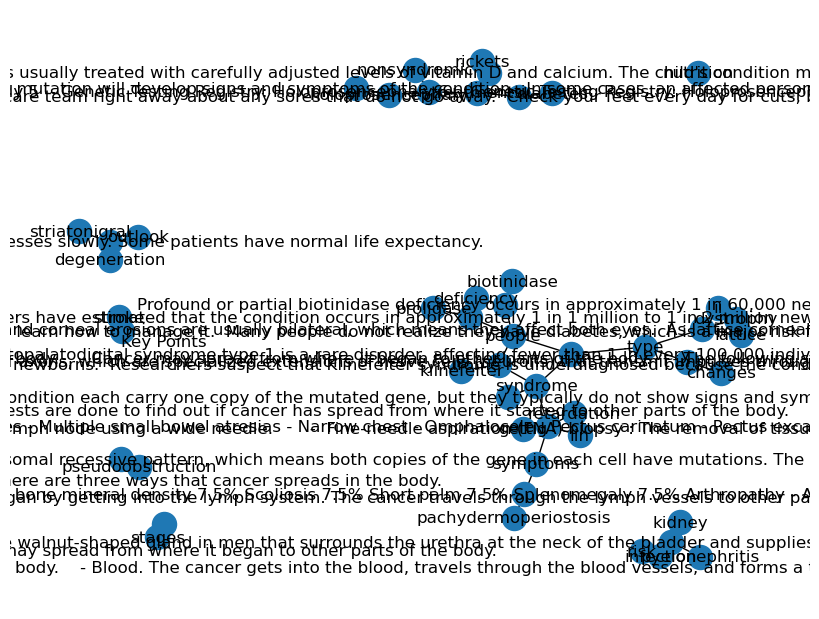

In [18]:
#plotting
plt.figure(figsize=(8,6))
subgraph = list(G.nodes())[:50]
nx.draw(G.subgraph(subgraph), with_labels=True)
plt.show()

In [19]:
#chatbot using Knowledge graph
def kg_chatbot(user_input):
    user_input = clean_text(user_input)
    entities = extract_entities(user_input)

    responses = []

    for ent in entities:
        if ent in G:
            neighbors = list(G.neighbors(ent))
            responses.extend(neighbors)

    if responses:
        return responses[0]
    else:
        return "Please consult a doctor."

In [20]:
#testing
kg_chatbot("what is diabetes")

"People with type 1 diabetes control their blood sugar with insulin -- either with shots or an insulin pen. Many people with type 2 diabetes can control blood glucose levels with diet and exercise alone. Others require oral medications or insulin, and some people may need to take both, along with lifestyle modification. (Watch the video to learn how one woman manages her type 2 diabetes. To enlarge the video, click the brackets in the lower right-hand corner. To reduce the video, press the Escape (Esc) button on your keyboard.) To manage your diabetes, here are things to do every day. -  Take your medicines for diabetes and for any other health problems, even when you feel good.  Take your medicines for diabetes and for any other health problems, even when you feel good. -  Keep track of your blood glucose (blood sugar). You may want to check it one or more times a day. Be sure to talk about it with your health care team.  Keep track of your blood glucose (blood sugar). You may want to

In [23]:
def label_category(text):
    text = text.lower()

    if "diabetes" in text:
        return "diabetes"
    elif "cancer" in text:
        return "cancer"
    elif "heart" in text:
        return "heart"
    elif "fever" in text:
        return "fever"
    else:
        return "general"

In [26]:
df["label"] = df["question"].apply(label_category)

In [27]:
print(df.columns)

Index(['question', 'answer', 'entities', 'label'], dtype='object')


In [28]:
#Train / Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["question"], df["label"], test_size=0.2, random_state=42
)

In [29]:
#Predictiong
def predict_label(text):
    text = text.lower()
    
    if "diabetes" in text:
        return "diabetes"
    elif "cancer" in text:
        return "cancer"
    elif "heart" in text:
        return "heart"
    else:
        return "general"

y_pred = [predict_label(q) for q in X_test]

In [30]:
#Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9933333333333333


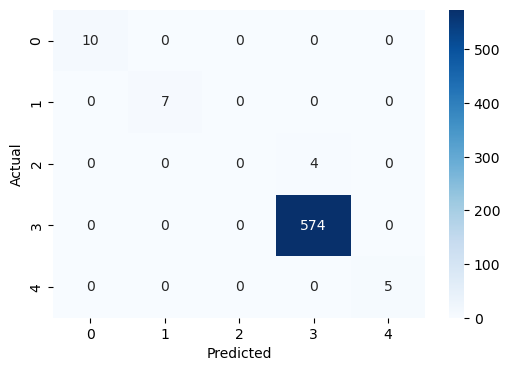

In [31]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

<Axes: >

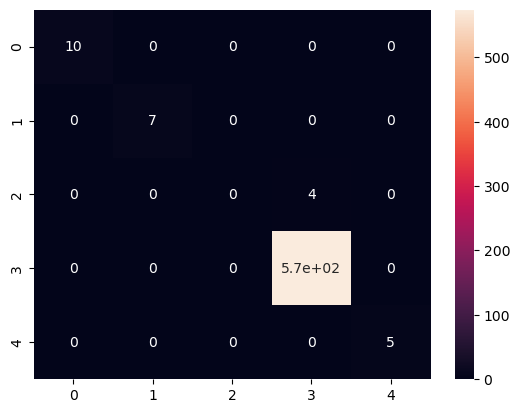

In [32]:
import seaborn as sns
sns.heatmap(cm ,annot=True)